# Geospatial Data Science - EEPS 440/460

# Lecture 14

# Cluster Analysis II

---

# Gaussian Mixture Model (GMM)

## Characteristics of GMM

- **Soft Clustering (Fuzzy Membership)**  
  Unlike K-means, where each data point belongs to only one cluster, GMM assigns a probability (or weight) to each data point for every cluster, allowing for partial membership.

- **Partitioning Approach**  
  GMM divides the n-dimensional space into \( k \) distinct clusters, ensuring that each region is uniquely assigned to a specific Gaussian component.

- **Complete Assignment**  
  Every data point is associated with a cluster based on the probability distribution, ensuring that all data points contribute to the clustering process.

GMM is particularly useful when clusters have different shapes, sizes, and densities, making it more flexible than K-means in capturing complex data distributions.

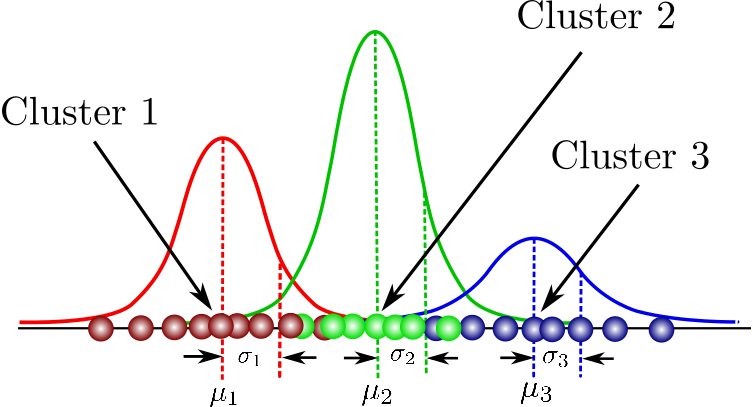

Source: https://towardsdatascience.com/gaussian-mixture-models-explained-6986aaf5a95

# Let's first review multivariate Gaussian distributions

# Bivariate Gaussian Distribution

### Probabilitiy density function

$$f(x,y) = \frac{1}{2\pi\sqrt{\sigma_X^2\sigma_Y^2(1-\rho^2)}}\exp\left({-\frac{1}{2(1-\rho^2)}\left[\frac{(x-\mu_X)^2}{\sigma^2_X} + \frac{(y-\mu_Y)^2}{\sigma^2_Y} - \frac{2\rho(x-\mu_X)(y-\mu_Y)}{\sigma_X\sigma_Y}\right]}\right)$$

Where $\mu_X$ and $\mu_Y$ are the means or expectations of $X$ and $Y$, $\sigma^2_X$ and $\sigma^2_Y$ are the variances of $X$ and $Y$, and $\rho$ is the linear correlation (Pearson correlation) between $X$ and $Y$.

Let's place $x$ and $y$ into a single vector $X$,

$$\mathbf{x} = \begin{bmatrix}
x\\
y\\
\end{bmatrix}$$

All the means into a single vector $\mu$,

$$\mathbf{\mu} = \begin{bmatrix}
\mu_X\\
\mu_Y\\
\end{bmatrix}$$


And all the variances and the covariance into a single covariance matrix $\mathbf{\Sigma}$:

$$\mathbf{\Sigma} = \begin{bmatrix}
\sigma^2_X&\text{cov}(X,Y)\\
\text{cov}(Y,X)&\sigma^2_Y\\
\end{bmatrix}$$

We can the define the bivariate distribution as:

$$f(X,Y) = \frac{\exp\left(-\frac{1}{2}(\mathbf{x} - \mathbf{\mu})^T\mathbf{\Sigma}^{-1}(\mathbf{x} - \mathbf{\mu})\right)}{\sqrt{(2\pi)^2|\mathbf{\Sigma}|}}$$

Where $|\mathbf{\Sigma}|$ is the determinant of $\mathbf{\Sigma}$.

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sns.set_style('darkgrid')
sns.set(rc={'axes.labelsize':25,
            'figure.figsize':(15.0, 15.0),
            'xtick.labelsize':15,
            'ytick.labelsize':15})
mu = np.array([2.5,2.0])
cov = np.array([[1.0,0.9],[0.9,1.0]])
X = np.random.multivariate_normal(mu,cov, 10000)
df = pd.DataFrame(data={'x':X[:,0],'y':X[:,1]})
sns.jointplot(x='x', y='y',data=df,kind='hex')
plt.show()

# Multivariate Gaussian Distribution

From our bivariate example, we can define the n-dimensional Gaussian distribution:

$$f(\mathbf{x}) = \frac{\exp\left(-\frac{1}{2}(\mathbf{x} - \mathbf{\mu})^T\mathbf{\Sigma}^{-1}(\mathbf{x} - \mathbf{\mu})\right)}{\sqrt{(2\pi)^{n}|\mathbf{\Sigma}|}}$$

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
mu = np.array([2.5,2.0,1.0])
cov = np.array([[1.0,0.9,0.5],
                [0.9,1.0,0.7],
                [0.5,0.7,1.0]])
X = np.random.multivariate_normal(mu,cov, 2000)
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0],X[:,1],X[:,2],s=40)
ax.set_xlabel('x',fontsize=25)
ax.set_ylabel('y',fontsize=25)
ax.set_zlabel('z',fontsize=25)
plt.show()

# Let's go back to the Gaussian Mixture Model

As an example, let's initialize three identical bivariate Gaussians that only differ in their means (we saw this example last lecture).

In [ ]:
sns.set_style('white')
np.random.seed(1)
mean = np.array([2.0,0.1])
cov = np.array([[1.0,0.3],[0.3,1.0]])
X0 = np.random.multivariate_normal(mean,cov,250)
mean = np.array([-5.0,2.0])
cov = np.array([[1.0,0.3],[0.3,1.0]])
X1 = np.random.multivariate_normal(mean,cov,250)
mean = np.array([-5.0,-5.0])
cov = np.array([[1.0,0.3],[0.3,1.0]])
X2 = np.random.multivariate_normal(mean,cov,250)
X = np.concatenate((X0,X1,X2),axis=0)
#Let's plot the synthetic clusters
plt.figure(figsize=(10,10))
plt.plot(X[:,0],X[:,1],'o')
plt.axis('equal')
plt.show()

# Clustering Using Gaussian Distributions

In this approach, clusters are modeled as **bivariate Gaussian distributions**, where each cluster follows a distinct probability distribution.

### Gaussian Mixture Model (GMM) Approach

- In theory, we can **fit** three bivariate Gaussian distributions to the data in order to determine the cluster assignments of each point.
- Beyond just assigning points to clusters, GMM allows us to compute a **probability (or weight)** for each data point, representing its degree of belonging to each of the three Gaussian distributions.
- This probabilistic assignment provides **greater flexibility** compared to hard clustering methods like K-means, capturing the uncertainty and overlapping nature of real-world data.

By leveraging these Gaussian distributions, we can model more complex cluster structures, accounting for varying shapes, densities, and orientations.

# Gaussian Mixture Model (GMM)

Let's assume that all data points in our dataset originate from a random variable $ \mathbf{X} $. To model them probabilistically, we define the probability density function (PDF) for a given point $ \mathbf{x}_n $ as:

$$
f(\mathbf{x}_n) = \sum_{i=1}^{k} \pi_i \mathcal{N}(\mathbf{x}_n | \mu_i, \Sigma_i)
$$

where:

- $ \mathcal{N}(\mathbf{x}_n | \mu_i, \Sigma_i) $ represents the probability density function of the **$ i $th multivariate Gaussian distribution**, characterized by:
  - **Mean**: $ \mu_i $ (center of the cluster)
  - **Covariance matrix**: $ \Sigma_i $ (spread and orientation of the cluster)
- $ \pi_i $ is the **mixing coefficient (or weight)** associated with the *i*th Gaussian component, representing the proportion of data points belonging to that cluster.
- The sum ensures that the total probability density integrates to 1, meaning GMM is a valid probability distribution.

This formulation allows GMM to model complex, multi-modal distributions by combining multiple Gaussian components, making it more flexible than traditional hard clustering methods.


# Fitting GMMs with the Expectation-Maximization (EM) Algorithm

The **Expectation-Maximization (EM)** algorithm is widely used for fitting **Gaussian Mixture Models (GMMs)**, which are a probabilistic model that assumes that the data is generated from a mixture of several Gaussian distributions. Here's a deeper look into how the algorithm works:

### Key Points:
- **K-means vs. Gaussian Mixture Models (GMMs)**: 
  - The **K-means** algorithm can be viewed as a simplified version of a **Gaussian Mixture Model (GMM)**. While K-means assigns each data point to exactly one cluster, GMMs allow for more flexibility by assigning each data point a probability of belonging to each cluster.
  - GMMs model the data as a combination of multiple Gaussian distributions, where each Gaussian corresponds to a cluster.
  
- **Expectation-Maximization (EM) Algorithm**:
  - The **EM algorithm** is an iterative method used to fit the parameters of a **GMM**.
  - It maximizes the likelihood function to find the best-fit model for the data. The key is that some parameters are hidden or "missing," and EM works to iteratively estimate those missing values.
  - The algorithm alternates between two steps:
    1. **Expectation (E-step)**: In this step, the algorithm calculates the expected values of the hidden variables (i.e., the probabilities of each data point belonging to each Gaussian component based on the current model).
    2. **Maximization (M-step)**: In this step, the algorithm re-estimates the model parameters (mean, covariance, and mixture weights) by maximizing the likelihood function using the values calculated in the E-step.
  
  The algorithm continues to iterate between the E-step and M-step until convergence, meaning the model parameters no longer change significantly between iterations.

### Steps of the EM Algorithm in the Context of GMMs:
1. **Initialization**: 
   - Start by initializing the parameters of the GMM, such as the means, covariances, and mixing coefficients (the weight of each Gaussian component).
   - Often, random initialization or K-means clustering can be used for initial values.

2. **E-step (Expectation)**:
   - For each data point, compute the responsibility of each Gaussian component, which is the probability that the data point belongs to that component.
   - This is done using **Bayes' theorem** to compute the posterior probability of each component given the data.

3. **M-step (Maximization)**:
   - Update the parameters of the Gaussian components (mean, covariance, and weight) based on the responsibilities computed in the E-step.
   - The parameters are updated to maximize the likelihood of the observed data under the current responsibilities.

4. **Convergence**: 
   - Repeat the E-step and M-step until the changes in the parameters are small enough, indicating that the algorithm has converged.

### Example: Fitting Two Bivariate Gaussians to 2D Data

Here is an example illustrating the process of fitting a **Gaussian Mixture Model** with **two bivariate Gaussian distributions** to a 2D dataset. The EM algorithm will iterate, updating the parameters of the two Gaussians to best fit the data.


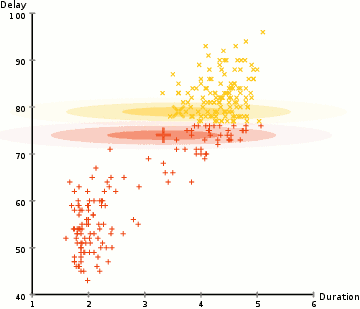


Source: https://en.wikipedia.org/wiki/File:EM_Clustering_of_Old_Faithful_data.gif

### Summary:
- The **EM algorithm** is a powerful method for fitting GMMs and can be thought of as an iterative process that refines the model parameters.
- While K-means assigns hard clusters to data points, GMMs provide a probabilistic approach, where each point belongs to a mixture of distributions, making GMMs more flexible for complex datasets.
- Although the underlying mechanics of EM can get mathematically complex, the general approach—alternating between estimating responsibilities and updating model parameters—is relatively straightforward.

If you are interested in the mathematical details or want to implement EM for GMMs, there are plenty of resources available online and in textbooks that dive deeper into the theory and steps involved.


# Let's apply GMM to our data

In [ ]:
import sklearn.mixture
#Set 3 clusters
k = 3
model = sklearn.mixture.GaussianMixture(n_components=k)
#Fit the model
model.fit(X)
#Predict the clusters on all the data
clusters = model.predict(X)
plt.figure(figsize=(10,10))
plt.scatter(X[:,0],X[:,1],c=clusters,cmap=plt.get_cmap('Paired'))
plt.scatter(model.means_[:,0],model.means_[:,1],c='k',s=100)
plt.axis('equal')
plt.show()

## Let's look at an example where K-means failed

#### 1. Initialize multivariate Gaussians with non-spherical covariance matrices

In [ ]:
np.random.seed(1)
mean = np.array([2.0,0.1])
cov = np.array([[1.0,0.9],[0.9,1.0]])
X0 = np.random.multivariate_normal(mean,cov,1000)
mean = np.array([-5.0,2.0])
cov = np.array([[5.0,1.0],[1.0,5.0]])
X1 = np.random.multivariate_normal(mean,cov,1000)
mean = np.array([-5.0,-5.0])
cov = np.array([[1.0,-0.9],[-0.9,1.0]])
X2 = np.random.multivariate_normal(mean,cov,1000)
X = np.concatenate((X0,X1,X2),axis=0)
#Let's plot the synthetic clusters
plt.figure(figsize=(10,10))
plt.plot(X[:,0],X[:,1],'o')
plt.axis('equal')
plt.show()

#### 2. Run K-means on the data

In [ ]:
#Set 3 clusters
k = 3
model = sklearn.cluster.KMeans(n_clusters=k)
#Fit the model
model.fit(X)
#Predict the clusters on all the data
clusters = model.predict(X)
plt.figure(figsize=(10,10))
plt.scatter(X[:,0],X[:,1],c=clusters,cmap=plt.get_cmap('Paired'))
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],c='k',s=100)
plt.axis('equal')
plt.show()

#### 3. Run GMM on the same data

In [ ]:
#Set 3 clusters
k = 3
model = sklearn.mixture.GaussianMixture(n_components=k)
#Fit the model
model.fit(X)
#Predict the clusters on all the data
clusters = model.predict(X)
plt.figure(figsize=(10,10))
plt.scatter(X[:,0],X[:,1],c=clusters,cmap=plt.get_cmap('Paired'))
plt.scatter(model.means_[:,0],model.means_[:,1],c='k',s=100)
plt.axis('equal')
plt.show()

Much better! GMM is able to account for non-spherical covariance matrices. This allows it to fit the "cigar" shapes. 

## Predicted weights of each bivariate Gaussian per data point 

In [ ]:
#Predict the weights per component
weights = model.predict_proba(X)
print(weights.shape)
plt.figure(figsize=(14,5))
plt.subplot(131)
plt.title('Component 1',fontsize=20)
plt.scatter(X[:,0],X[:,1],c=weights[:,0],cmap=plt.get_cmap('jet'),vmin=0,vmax=1)
cb = plt.colorbar(orientation='horizontal')
plt.subplot(132)
plt.title('Component 2',fontsize=20)
plt.scatter(X[:,0],X[:,1],c=weights[:,1],cmap=plt.get_cmap('jet'),vmin=0,vmax=1)
cb = plt.colorbar(orientation='horizontal')
plt.subplot(133)
plt.title('Component 3',fontsize=20)
plt.scatter(X[:,0],X[:,1],c=weights[:,2],cmap=plt.get_cmap('jet'),vmin=0,vmax=1)
cb = plt.colorbar(orientation='horizontal')
plt.suptitle('Weights of each component',y=1.05,fontsize=25)
#plt.tight_layout()
plt.show()

## We still need to worry about scaling our data

#### 1. Initialize multivariate Gaussians with non-spherical covariance matrices

In [ ]:
np.random.seed(1)
mean = np.array([100.0,1.0])
cov = np.array([[500.0,0.1],[0.1,5.0]])
X0 = np.random.multivariate_normal(mean,cov,1000)
mean = np.array([-5.0,2.0])
cov = np.array([[1.0,0.3],[0.3,1.0]])
X1 = np.random.multivariate_normal(mean,cov,250)
mean = np.array([-5.0,-5.0])
cov = np.array([[1.0,0.3],[0.3,1.0]])
X2 = np.random.multivariate_normal(mean,cov,250)
X = np.concatenate((X0,X1,X2),axis=0)
#Let's plot the synthetic clusters
plt.figure(figsize=(10,10))
plt.plot(X[:,0],X[:,1],'o')
#plt.axis('equal')
plt.show()

#### 2. Run GMM on the data

In [ ]:
Xn = (X - np.min(X,axis=0))/(np.max(X,axis=0)-np.min(X,axis=0)) 
#Set 3 clusters
k = 3
model = sklearn.mixture.GaussianMixture(n_components=k,n_init=10)
#Fit the model
model.fit(Xn)
#Predict the clusters on all the data
clusters = model.predict(Xn)
plt.figure(figsize=(10,10))
plt.scatter(Xn[:,0],Xn[:,1],c=clusters,cmap=plt.get_cmap('Paired'))
plt.scatter(model.means_[:,0],model.means_[:,1],c='k',s=100)
#plt.axis('equal')
plt.show()

# GMM: Be careful with initialization!

In [ ]:
Xn = (X - np.min(X,axis=0))/(np.max(X,axis=0)-np.min(X,axis=0)) 
#Set 3 clusters
k = 3
model = sklearn.mixture.GaussianMixture(n_components=k,n_init=1)
#Fit the model
model.fit(Xn)
#Predict the clusters on all the data
clusters = model.predict(Xn)
plt.figure(figsize=(10,10))
plt.scatter(Xn[:,0],Xn[:,1],c=clusters,cmap=plt.get_cmap('Paired'))
plt.scatter(model.means_[:,0],model.means_[:,1],c='k',s=100)
#plt.axis('equal')
plt.show()

To avoid ending up at a "bad" local minima, run GMM run multiple times via the `n_init` parameter. It will then choose the best fit.

# Let's apply GMM to our "dove" from last lecture

In [ ]:
#Import data
import rasterio
import numpy as np
data = {}
file = '../Workspace/dem.tif'
data['dem'] = rasterio.open(file).read(1)
file = '../Workspace/ppt.tif'
data['ppt'] = rasterio.open(file).read(1)
file = '../Workspace/tmean.tif'
data['tmean'] = rasterio.open(file).read(1)
file = '../Workspace/treecover.tif'
data['tcf'] = rasterio.open(file).read(1)
file = '../Workspace/barecover.tif'
data['bcf'] = rasterio.open(file).read(1)
file = '../Workspace/sand.tif'
data['sand'] = rasterio.open(file).read(1)
#Create lats/lons arrays
fp = rasterio.open(file)
lons = np.linspace(fp.bounds.left+fp.res[0]/2,fp.bounds.right-fp.res[0]/2,data['sand'].shape[1])
lats = np.linspace(fp.bounds.bottom+fp.res[1]/2,fp.bounds.top-fp.res[1]/2,data['sand'].shape[0])
(lons,lats) = np.meshgrid(lons,lats)
#(lons,lats) = np.meshgrid(lats,lons)
data['lon'] = lons[:]
data['lat'] = np.flipud(lats[:])

#### 1. Run GMM on the data

In [ ]:
import sklearn.mixture
#Bring in the data
v1 = data['dem'].reshape(data['dem'].size)
v2 = data['bcf'].reshape(data['bcf'].size)
#Create data for scikit-learn
X = np.stack((v1,v2)).T
#Normalize the data
Xn = (X - np.min(X,axis=0))/(np.max(X,axis=0)-np.min(X,axis=0))
#Define the number of clusters
k = 4
np.random.seed(1)
model = sklearn.mixture.GaussianMixture(n_components=k,n_init=3)
#Subsample data to fit the model (minimize computation)
idx = np.random.choice(np.arange(X.shape[0]),5000)
Xs = X[idx,:]
#Fit the model
model.fit(Xs)
#Predict the clusters on all the data
clusters = model.predict(X)
plt.figure(figsize=(14,6))
plt.title('Assigned clusters',fontsize=20)
plt.scatter(data['dem'].reshape(data['dem'].size),data['bcf'].reshape(data['bcf'].size),
            c=clusters,cmap=plt.get_cmap('viridis'),alpha=0.03)
cb = plt.colorbar()
#Ensure the alpha of the colorbar is 1.0
cb.solids.set_alpha(1.0)
plt.xlabel('Elevation (m)',fontsize=20)
plt.ylabel('Bare cover fraction (%)',fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

#### 2. Show associated weights

In [ ]:
#Predict the weights per component
weights = model.predict_proba(X)
plt.figure(figsize=(14,10))
plt.subplot(221)
plt.title('Component 1',fontsize=20)
plt.scatter(X[:,0],X[:,1],c=weights[:,0],cmap=plt.get_cmap('jet'),vmin=0,vmax=1)
cb = plt.colorbar(orientation='horizontal')
cb.solids.set_alpha(1.0)
plt.subplot(222)
plt.title('Component 2',fontsize=20)
plt.scatter(X[:,0],X[:,1],c=weights[:,1],cmap=plt.get_cmap('jet'),vmin=0,vmax=1)
cb = plt.colorbar(orientation='horizontal')
plt.subplot(223)
plt.title('Component 3',fontsize=20)
plt.scatter(X[:,0],X[:,1],c=weights[:,2],cmap=plt.get_cmap('jet'),vmin=0,vmax=1)
cb = plt.colorbar(orientation='horizontal')
plt.subplot(224)
plt.title('Component 4',fontsize=20)
plt.scatter(X[:,0],X[:,1],c=weights[:,3],cmap=plt.get_cmap('jet'),vmin=0,vmax=1)
cb = plt.colorbar(orientation='horizontal')
plt.suptitle('Weights of each component',y=1.05,fontsize=25)
#plt.tight_layout()
plt.show()

# Reproduce original maps

In [ ]:
#Assign the cluster centroid values to each cluster
Xpred = np.copy(X)
for i in range(k):
    m = clusters == i
    Xpred[m,:] = np.mean(X[m,:],axis=0)
dem_pred = Xpred[:,0].reshape(data['dem'].shape)
bcf_pred = Xpred[:,1].reshape(data['bcf'].shape)

In [ ]:
#Create a figure comparing them
#Compare the two
vmin = np.min(data['dem'])
vmax = np.max(data['dem'])
plt.figure(figsize=(15,12))
plt.subplot(221)
plt.imshow(data['dem'],vmin=vmin,vmax=vmax,cmap=plt.get_cmap('terrain'))
plt.ylabel('Elevation',fontsize=25)
plt.title('Original',fontsize=25)
plt.xticks([])
plt.yticks([])
cb = plt.colorbar(orientation='horizontal',pad=0.03,shrink=0.90)
cb.ax.tick_params(labelsize=16)
plt.subplot(222)
plt.title('Reproduced for k=%i' % k,fontsize=25)
plt.imshow(dem_pred,vmin=vmin,vmax=vmax,cmap=plt.get_cmap('terrain'))
plt.xticks([])
plt.yticks([])
cb = plt.colorbar(orientation='horizontal',pad=0.03,shrink=0.90)
cb.ax.tick_params(labelsize=16)
vmin = np.min(data['bcf'])
vmax = np.max(data['bcf'])
plt.subplot(223)
plt.imshow(data['bcf'],vmin=vmin,vmax=vmax,cmap=plt.get_cmap('YlGn_r'))
plt.ylabel('Bare cover fraction',fontsize=25)
plt.xticks([])
plt.yticks([])
cb = plt.colorbar(orientation='horizontal',pad=0.03,shrink=0.90)
cb.ax.tick_params(labelsize=16)
plt.subplot(224)
plt.imshow(bcf_pred,vmin=vmin,vmax=vmax,cmap=plt.get_cmap('YlGn_r'))
plt.xticks([])
plt.yticks([])
cb = plt.colorbar(orientation='horizontal',pad=0.03,shrink=0.90)
cb.ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

# Reproduce original maps: Leverage weights to compute the mean values for each cluster

In [ ]:
#Xpred = np.copy(X)
#for i in range(k):
#    m = clusters == i
#    #Sum using weights
#    Xpred[m,:] = np.sum(weights[m,:,np.newaxis]*model.means_[np.newaxis,:,:],axis=1)
Xpred = np.sum(weights[:,:,np.newaxis]*model.means_[np.newaxis,:,:],axis=1)
dem_pred = Xpred[:,0].reshape(data['dem'].shape)
bcf_pred = Xpred[:,1].reshape(data['bcf'].shape)

In [ ]:
#Create a figure comparing them
#Compare the two
vmin = np.min(data['dem'])
vmax = np.max(data['dem'])
plt.figure(figsize=(15,12))
plt.subplot(221)
plt.imshow(data['dem'],vmin=vmin,vmax=vmax,cmap=plt.get_cmap('terrain'))
plt.ylabel('Elevation',fontsize=25)
plt.title('Original',fontsize=25)
plt.xticks([])
plt.yticks([])
cb = plt.colorbar(orientation='horizontal',pad=0.03,shrink=0.90)
cb.ax.tick_params(labelsize=16)
plt.subplot(222)
plt.title('Reproduced for k=%i' % k,fontsize=25)
plt.imshow(dem_pred,vmin=vmin,vmax=vmax,cmap=plt.get_cmap('terrain'))
plt.xticks([])
plt.yticks([])
cb = plt.colorbar(orientation='horizontal',pad=0.03,shrink=0.90)
cb.ax.tick_params(labelsize=16)
vmin = np.min(data['bcf'])
vmax = np.max(data['bcf'])
plt.subplot(223)
plt.imshow(data['bcf'],vmin=vmin,vmax=vmax,cmap=plt.get_cmap('YlGn_r'))
plt.ylabel('Bare cover fraction',fontsize=25)
plt.xticks([])
plt.yticks([])
cb = plt.colorbar(orientation='horizontal',pad=0.03,shrink=0.90)
cb.ax.tick_params(labelsize=16)
plt.subplot(224)
plt.imshow(bcf_pred,vmin=vmin,vmax=vmax,cmap=plt.get_cmap('YlGn_r'))
plt.xticks([])
plt.yticks([])
cb = plt.colorbar(orientation='horizontal',pad=0.03,shrink=0.90)
cb.ax.tick_params(labelsize=16)
plt.tight_layout()
plt.show()

It helps define smoother boundaries between the mapped out clusters

# GMM Summary I

## Characteristics

- **Soft Clustering (Fuzzy Membership)**  
  Each data point is assigned a probability of belonging to every cluster, unlike K-means, which enforces hard assignments.

- **Partitioning Approach**  
  The algorithm divides the $n$-dimensional space into $k$ distinct, non-overlapping clusters.

- **Complete Assignment**  
  Every data point is associated with at least one cluster, ensuring full data representation.



# GMM Summary II

## Advantages

- **Flexible Cluster Shapes**  
  Can model clusters with non-spherical distributions, unlike K-means, which assumes circular clusters.

- **Soft Assignment (Fuzzy Clustering)**  
  Assigns probabilities to data points instead of hard labels, allowing for better representation of uncertainty.

- **Effective Data Partitioning**  
  Useful for vector quantization and probabilistic modeling of datasets.

## Disadvantages

- **Computational Complexity**  
  Estimating the covariance matrix for multiple Gaussians increases the computational burden, making it less scalable.

- **Local Minima Sensitivity**  
  The algorithm may converge to suboptimal solutions depending on the initialization of centroids, requiring multiple runs or careful initialization.

___

# Shapes of clusters where both K-means and GMM fail

#### 1. Make some data

In [ ]:
import sklearn.datasets
n_samples = 1500
X = sklearn.datasets.make_circles(n_samples=n_samples, factor=.5,noise=.05)[0]
plt.figure(figsize=(10,10))
plt.plot(X[:,0],X[:,1],'bo')
plt.show()

#### 2. Fit and plot both K-means and GMM

In [ ]:
#Set 2 clusters
k = 2
#K-means
model = sklearn.cluster.KMeans(n_clusters=k)
#Fit the model
model.fit(X)
#Predict the clusters on all the data
clusters = model.predict(X)
plt.figure(figsize=(13,5))
plt.subplot(121)
plt.title('K-means',fontsize=20)
plt.scatter(X[:,0],X[:,1],c=clusters,cmap=plt.get_cmap('Paired'))
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],c='k',s=100)
#GMM
model = sklearn.mixture.GaussianMixture(n_components=k)
#Fit the model
model.fit(X)
#Predict the clusters on all the data
clusters = model.predict(X)
plt.subplot(122)
plt.title('GMM',fontsize=20)
plt.scatter(X[:,0],X[:,1],c=clusters,cmap=plt.get_cmap('Paired'))
plt.scatter(model.means_[:,0],model.means_[:,1],c='k',s=100)
plt.show()

The mean is not useful to define these clusters

We are going to explore some alternatives that allow us to solve these problems

# Option 1: Hierarchical clustering

Note: The source of the following slides is: https://www-users.cs.umn.edu/~kumar001/dmbook/index.php

The slides themselves are derived from "Introduction to Data Mining" (Tan et al., 2019). 

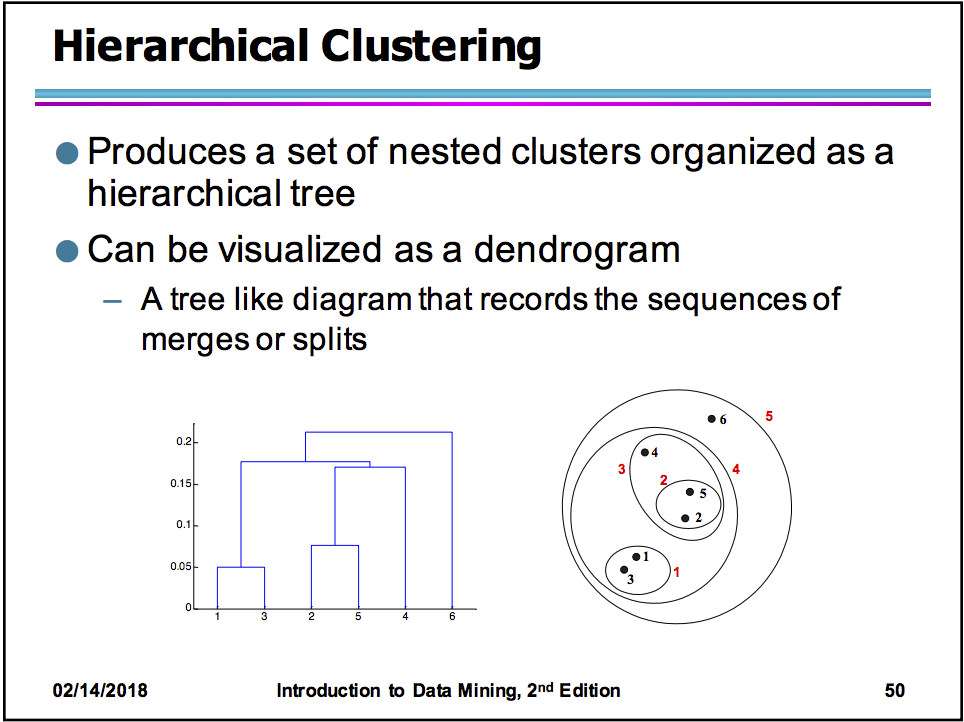

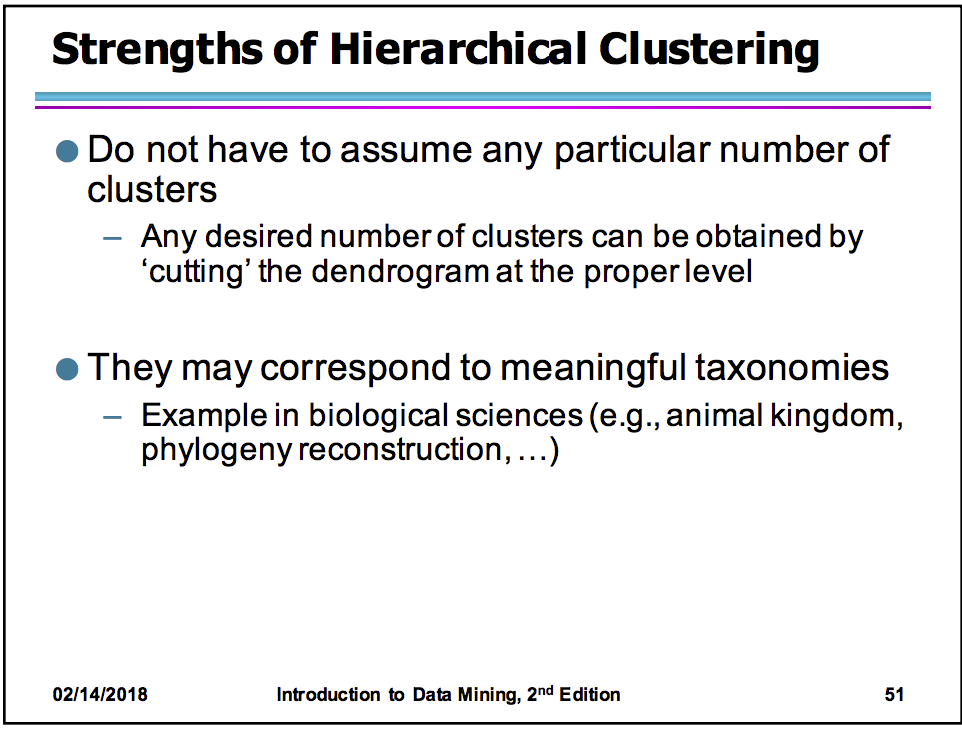

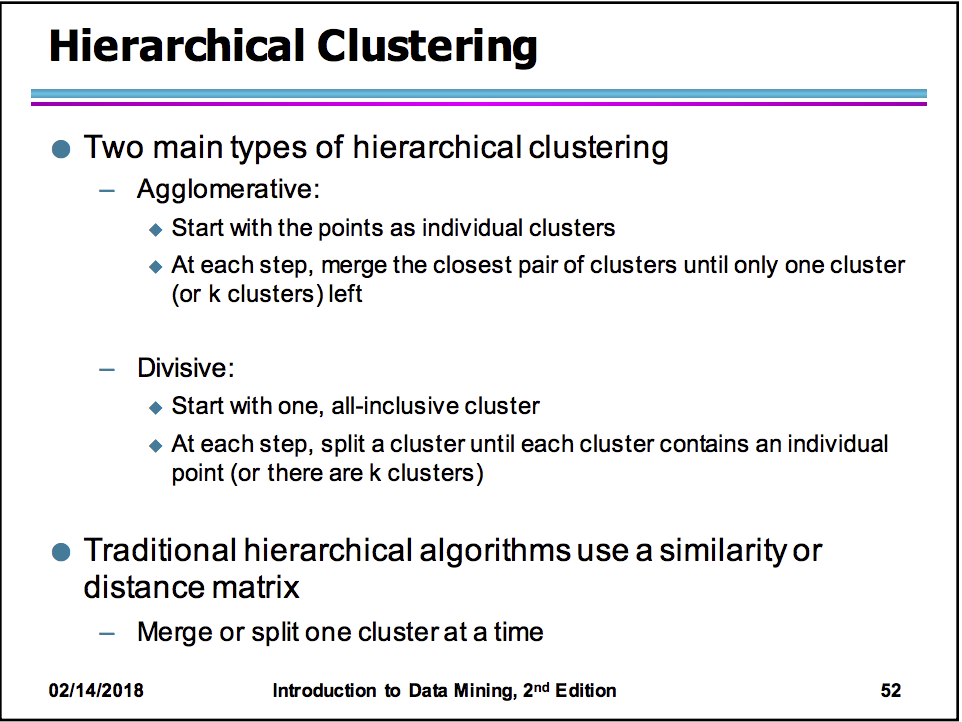

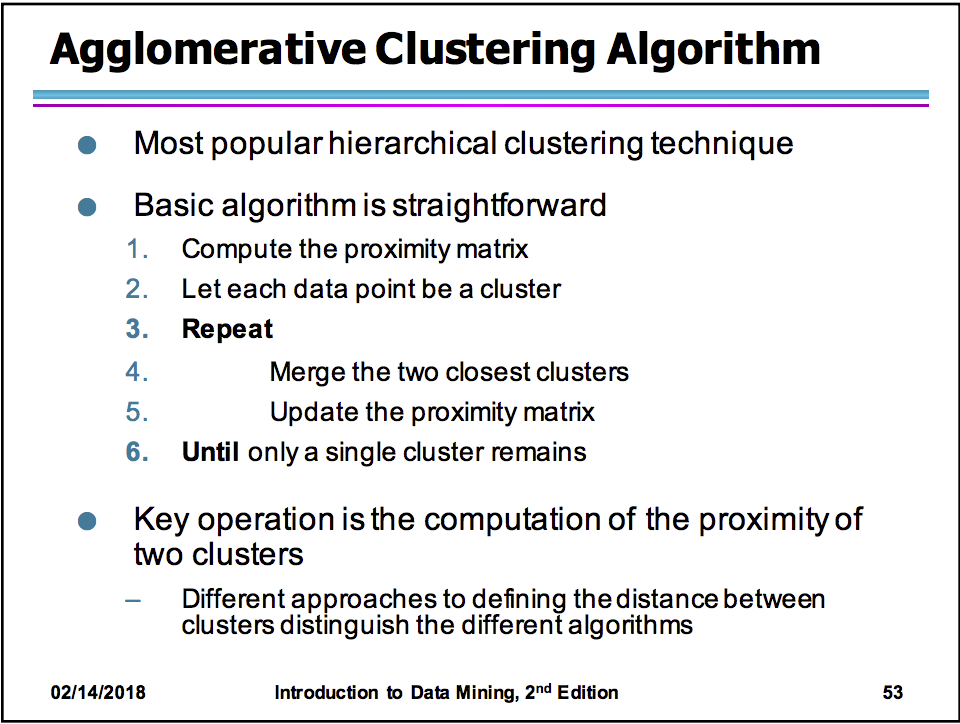

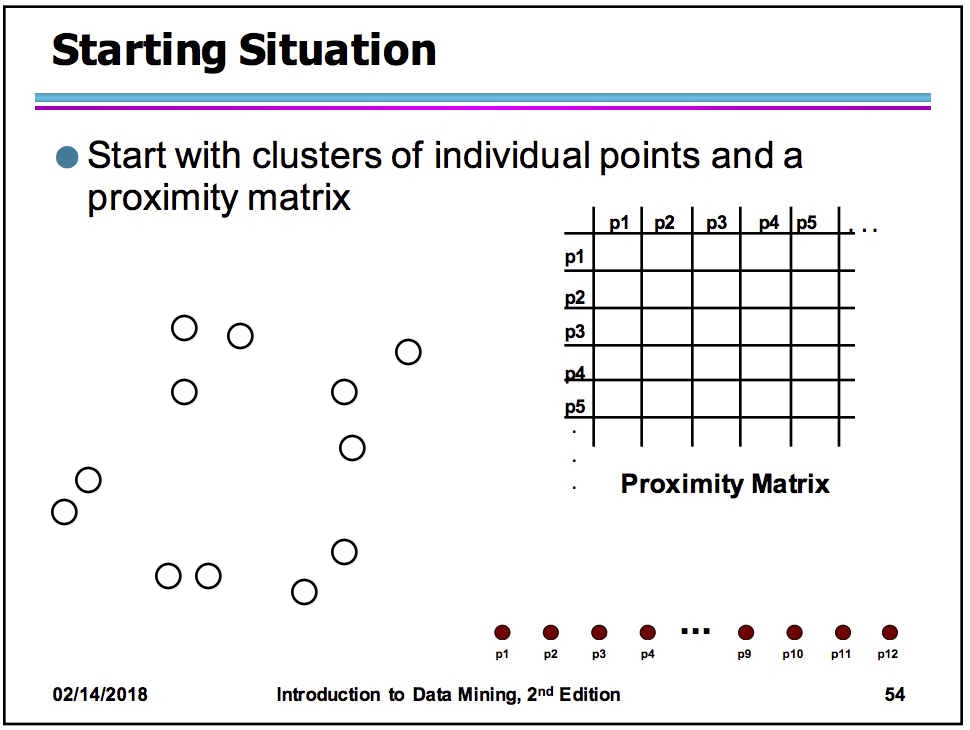

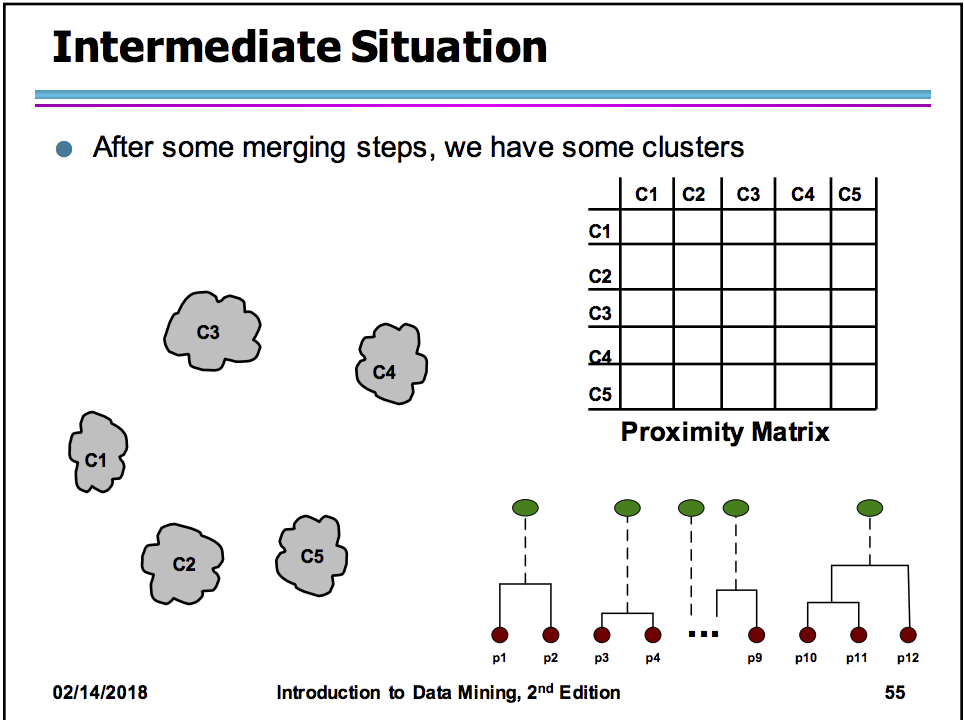

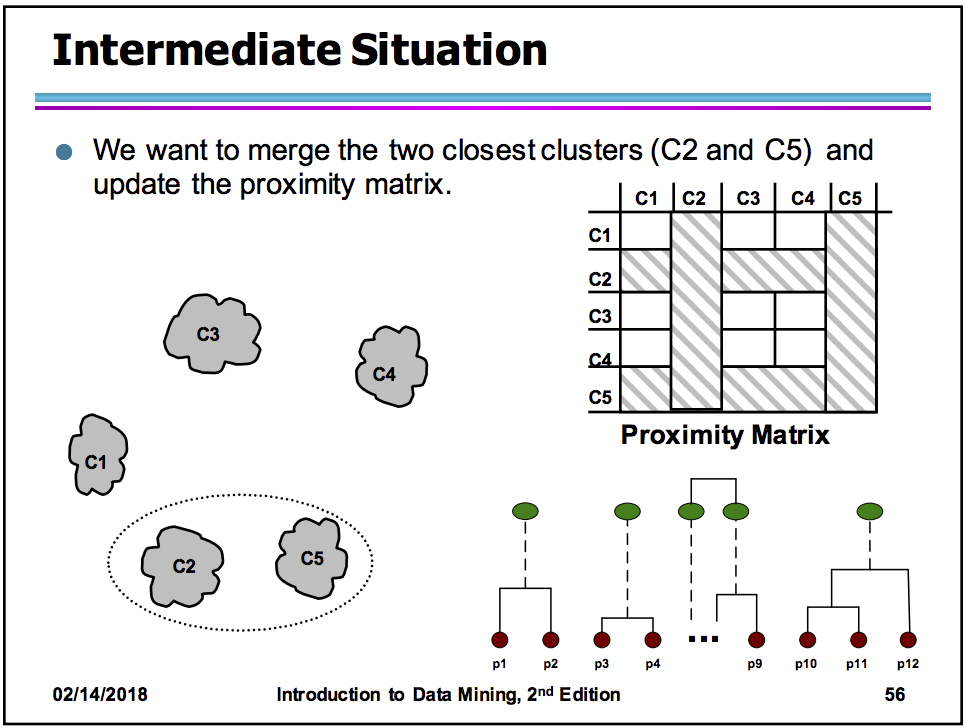

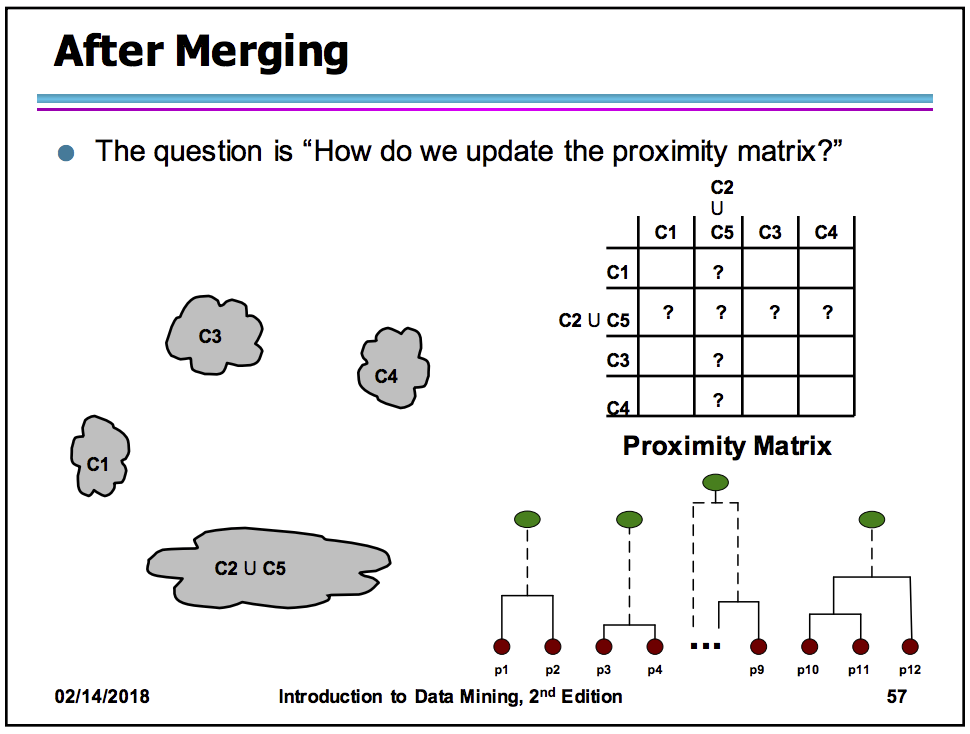

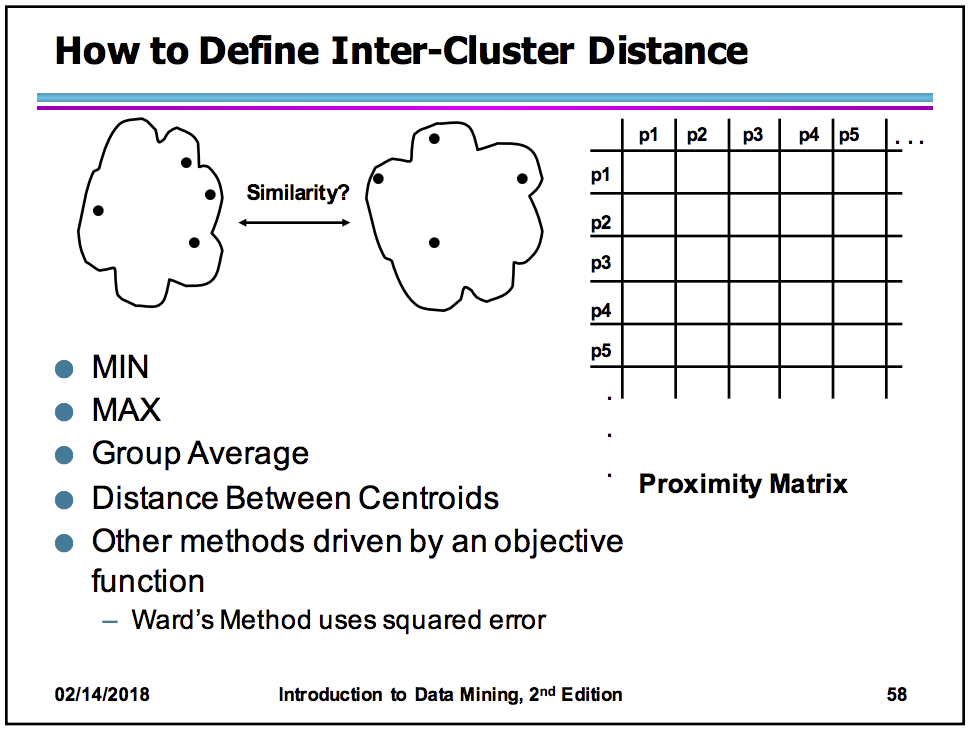

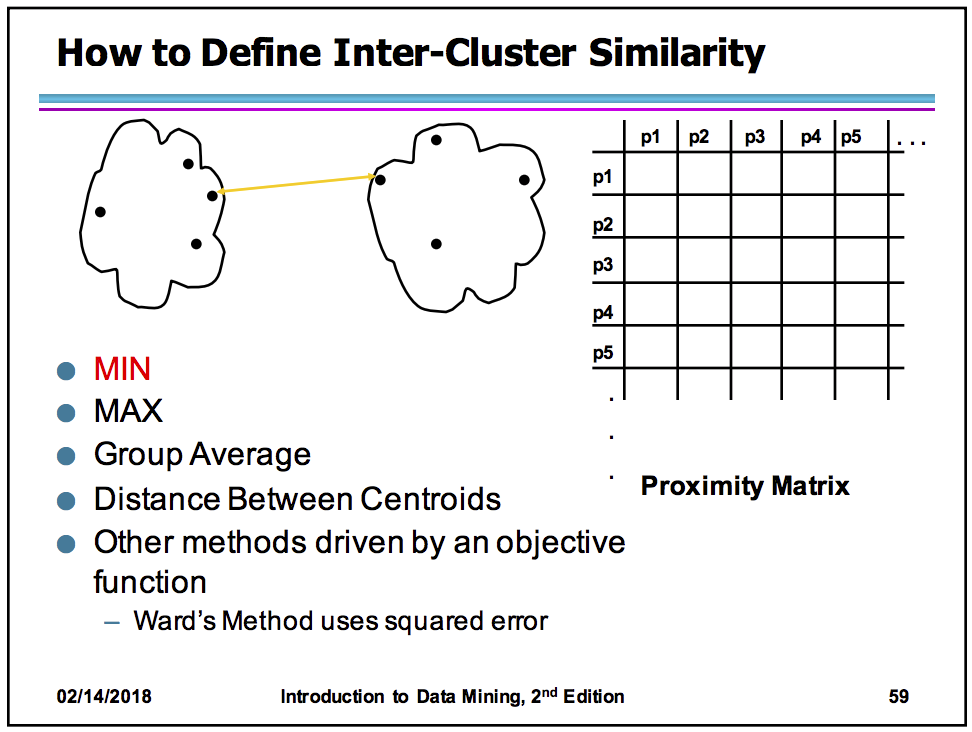

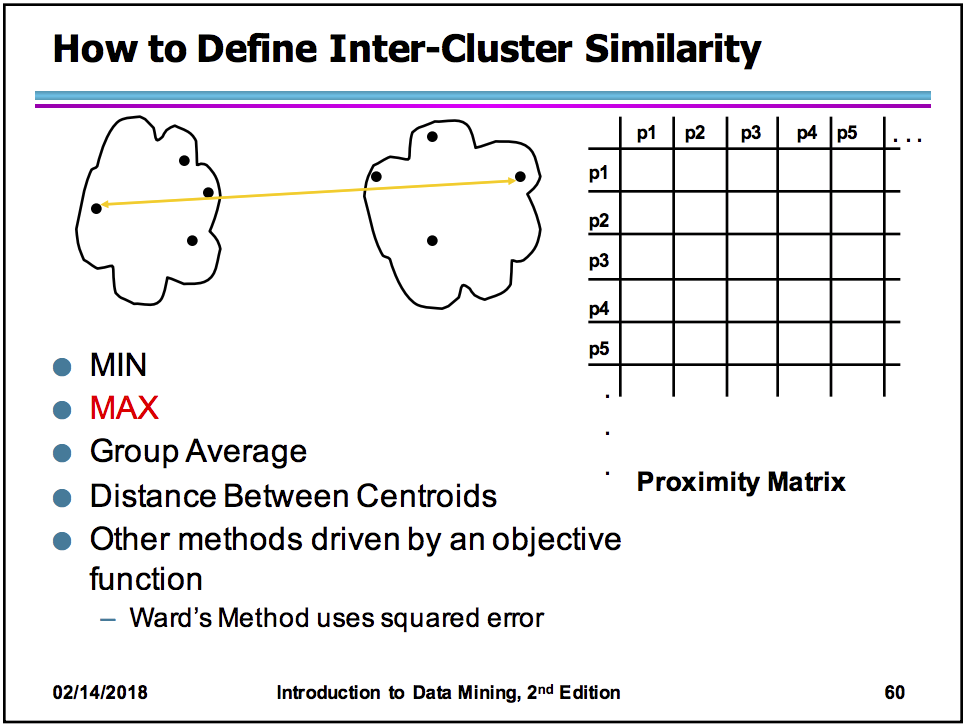

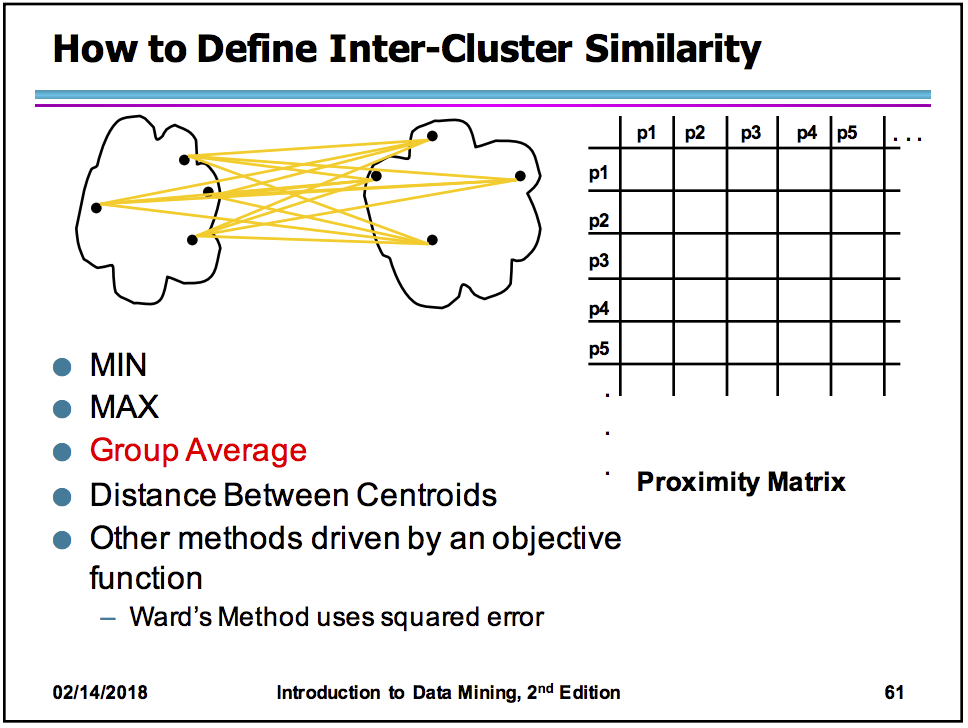

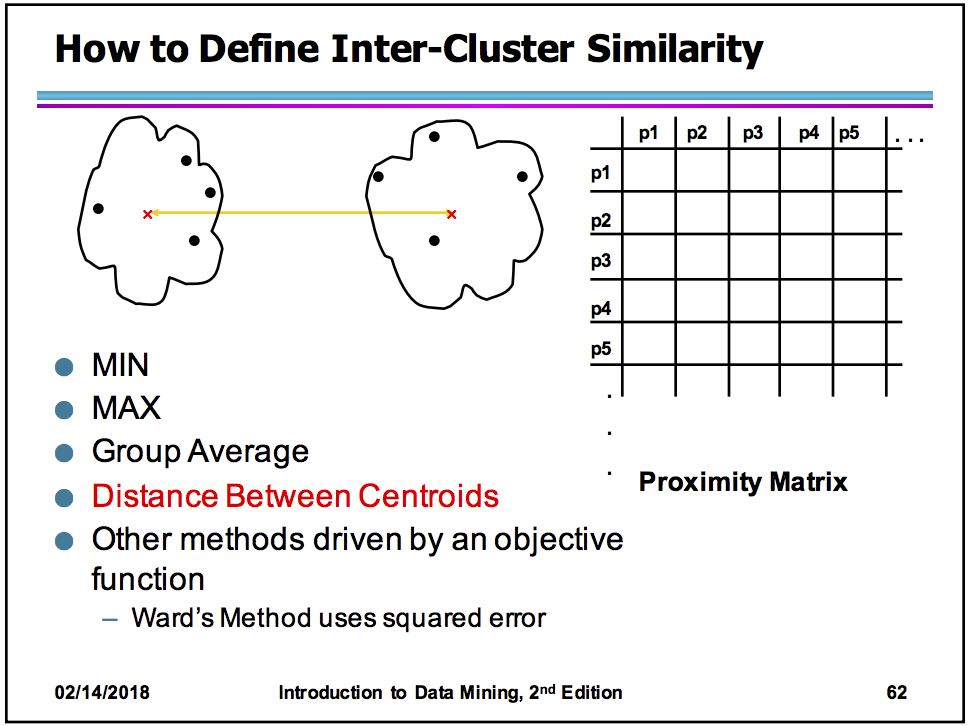

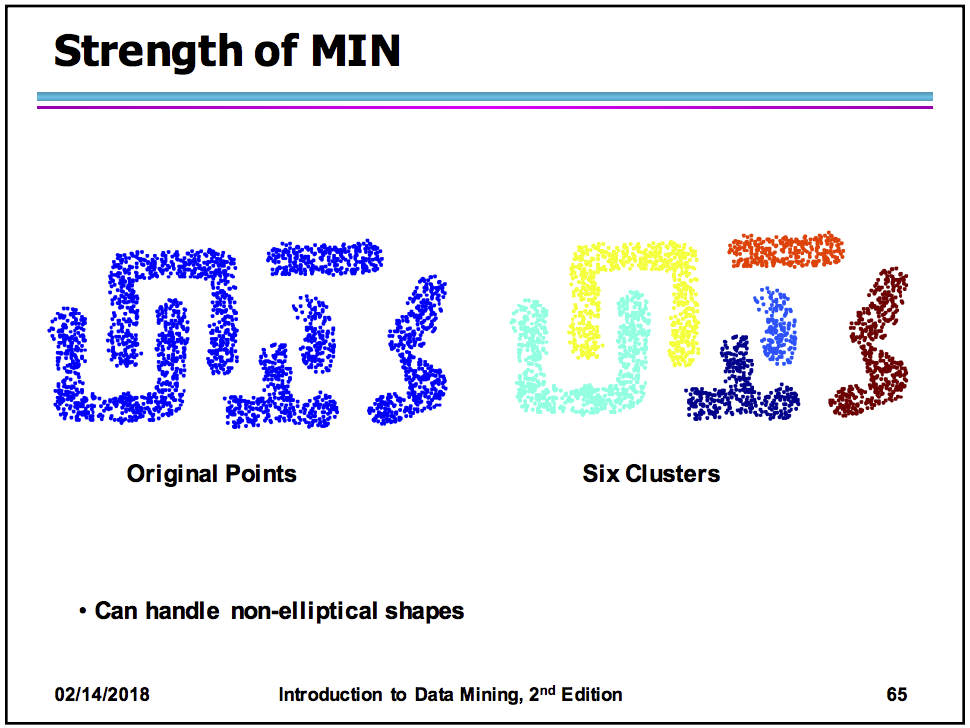

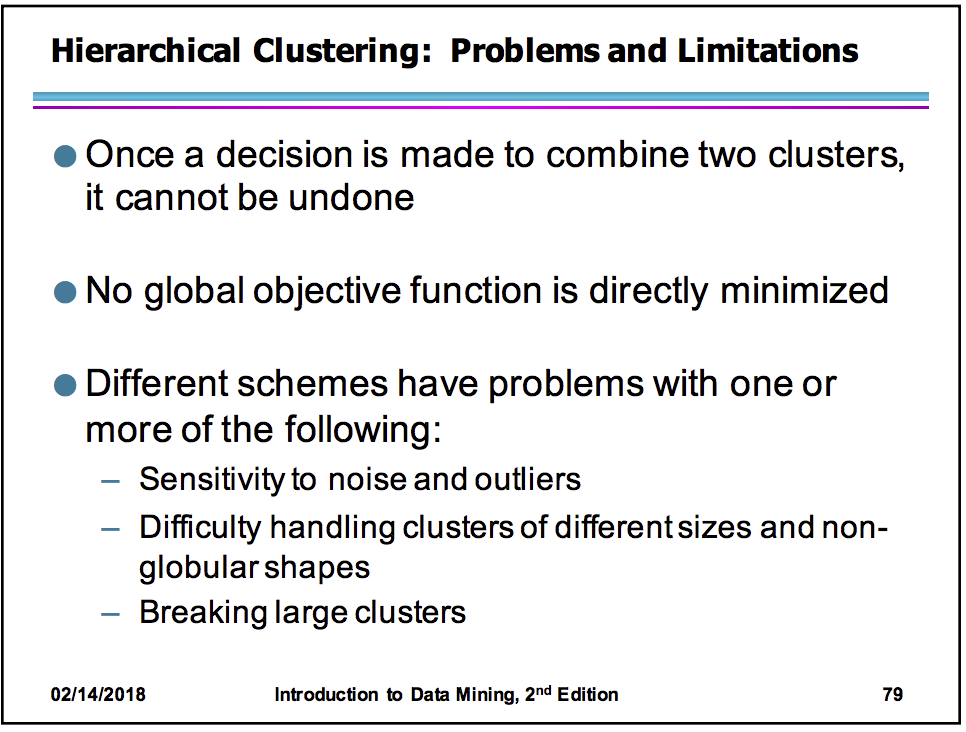

# Agglomerative Clustering Example: Single Linkage (MIN)

In [ ]:
#Set 2 clusters
k = 2
model = sklearn.cluster.AgglomerativeClustering(n_clusters=k,linkage='single')
#Predict the clusters on all the data
clusters = model.fit_predict(X)
plt.figure(figsize=(10,10))
plt.title('Agglomerative Clustering (single linkage)',fontsize=20)
plt.scatter(X[:,0],X[:,1],c=clusters,cmap=plt.get_cmap('Paired'))
plt.show()

# Option 2: Density-based clustering

Note: The source of the following slides is: https://www-users.cs.umn.edu/~kumar001/dmbook/index.php

The slides themselves are derived from "Introduction to Data Mining" (Tan et al., 2019).

# DBSCAN

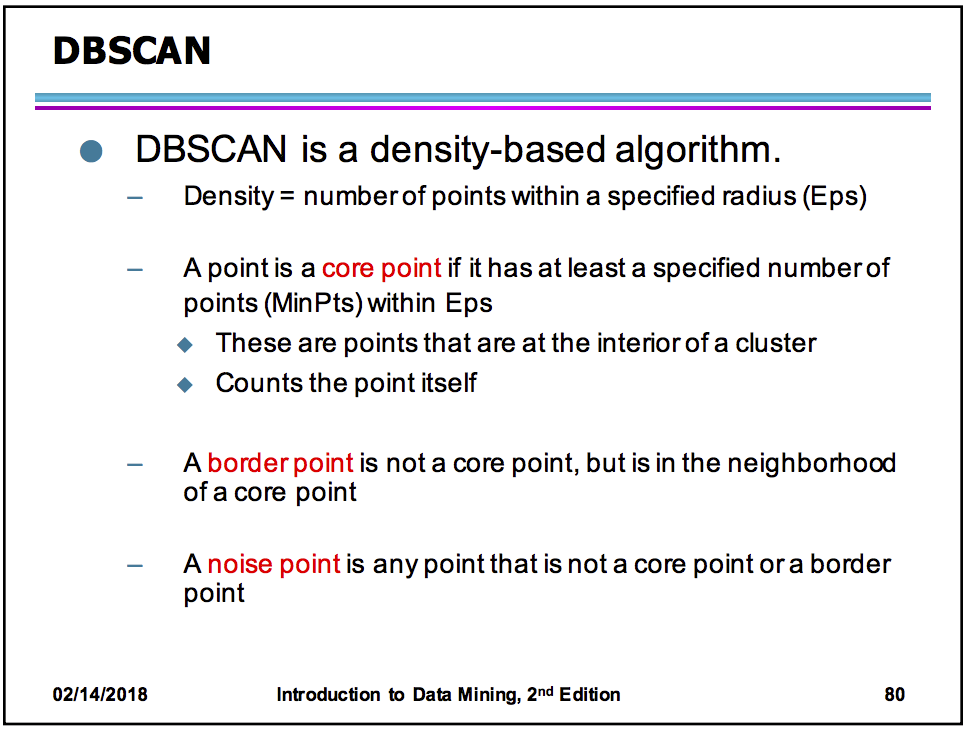

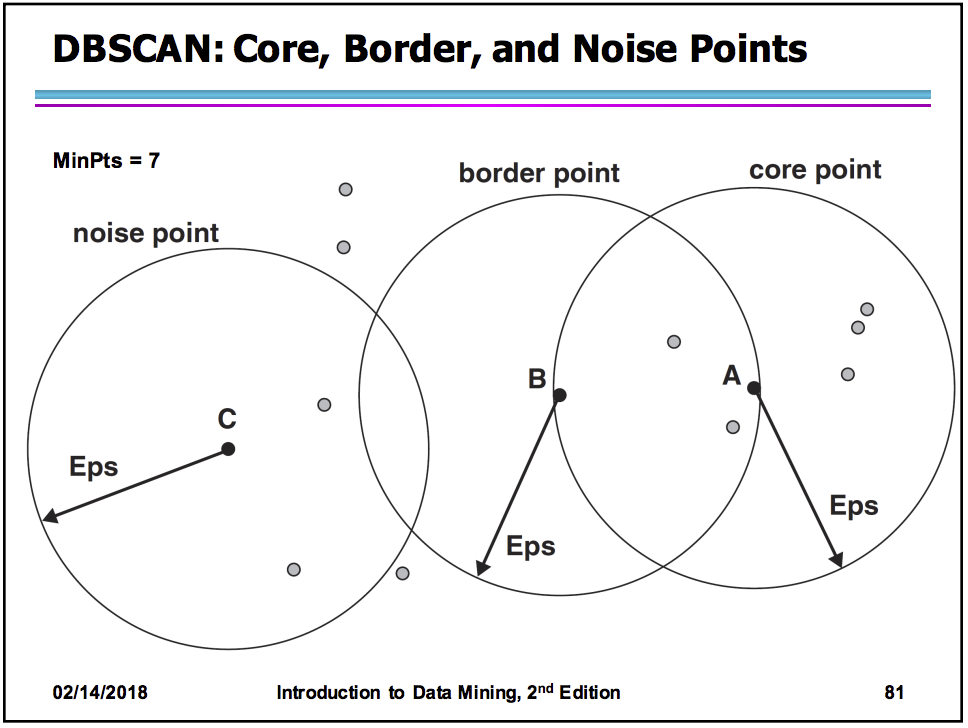

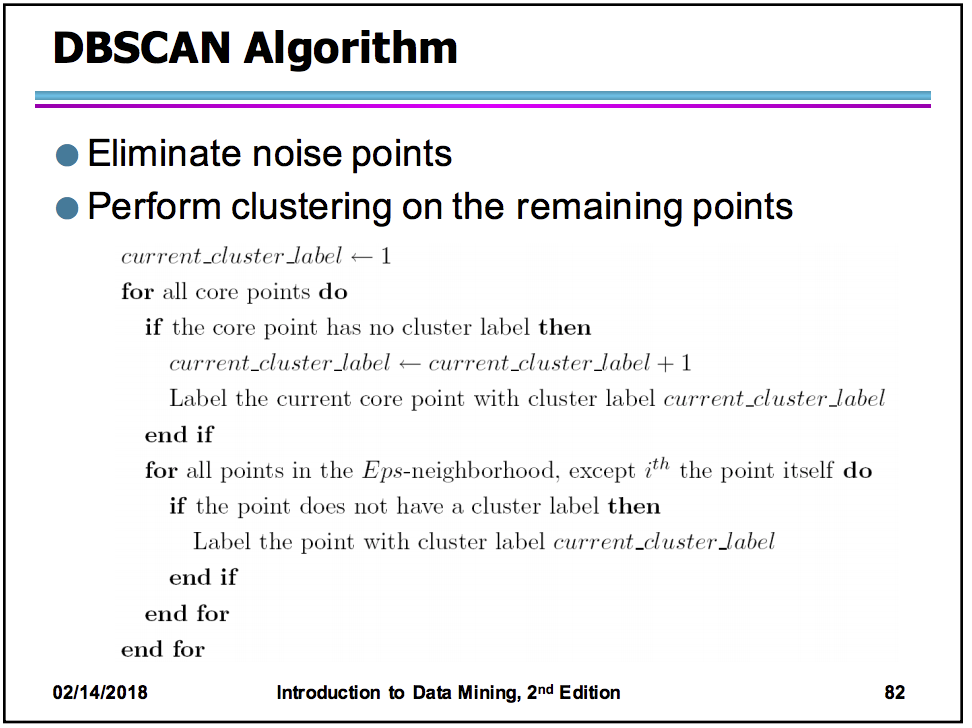

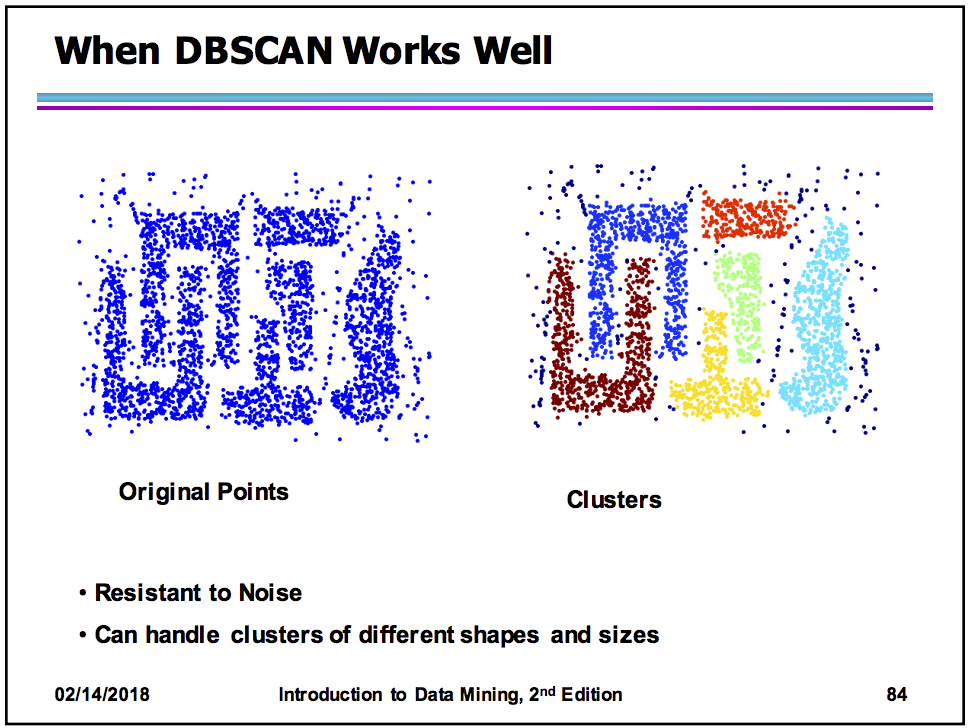

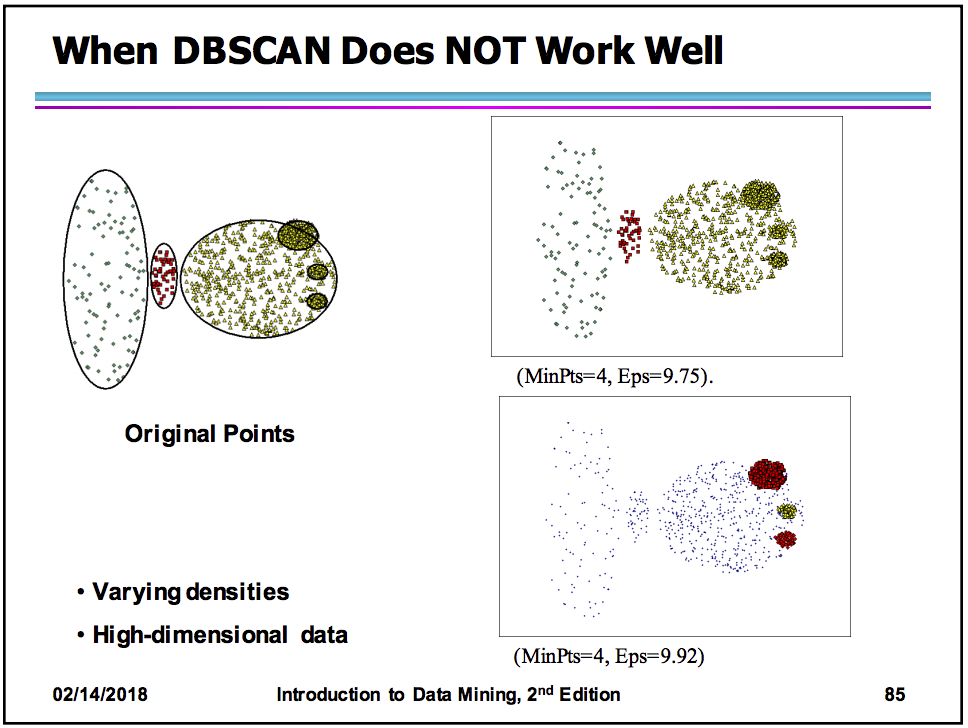

In [ ]:
#Set 2 clusters
k = 2
#model = sklearn.cluster.AgglomerativeClustering(n_clusters=k,linkage='single')
model = sklearn.cluster.DBSCAN(eps=0.25, min_samples=100)
#Predict the clusters on all the data
clusters = model.fit_predict(X)
plt.figure(figsize=(13,5))
plt.subplot(121)
plt.title('DBSCAN',fontsize=20)
plt.scatter(X[:,0],X[:,1],c=clusters,cmap=plt.get_cmap('Paired'))
plt.show()

## Cluster analysis seeks to reduce the sample size. 

## We are going to look at dimensionality reduction next